### Importing Libraries

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Connecting to the SQL Database

In [122]:
import sqlite3
connection = sqlite3.connect(r'C:/Users/HP/Desktop/NordexShiftOptimizationSystem/ShiftData.db')
Shift_Data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
Shift_Data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


### Basic Dataset Overview

* Shift_Data.columns - List the column names in the dataset
* Shift_Data.shape - getting the shape of the dataset
* Format the data to proper date format
* df.duplicated().sum() - checking for duplicates in our dataset
* df.isna().sum() - checking for missing values in the dataset
* df.describe() - CHecking the statistical Distribution of our dataset


In [123]:
Shift_Data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [124]:
Shift_Data.shape

(296334, 31)

In [125]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [126]:
# properly formatting our columns that has the datatype of date into proper datatime format

Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])
Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['timestamp'] = pd.to_datetime(Shift_Data['timestamp'])


C:\Users\HP\AppData\Local\Temp\ipykernel_9008\2213221887.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
C:\Users\HP\AppData\Local\Temp\ipykernel_9008\2213221887.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])


In [127]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [128]:
# this cells checks if the dataset has duplicates
Shift_Data.duplicated().sum()

0

In [129]:
## This cells checks if the dataset has missing values
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [130]:
## This Cells checks the statisical distribution of our dataset
Shift_Data.describe()

,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity,timestamp
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000,295129
mean,2.048142,2026-06-04 14:23:06.478770688,2026-06-04 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118,2024-02-15 04:22:59.795276288
min,1.000000,2026-06-04 06:00:00,2026-06-04 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000,2024-01-01 08:00:00
25%,1.000000,2026-06-04 06:00:00,2026-06-04 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000,2024-01-23 08:00:00
50%,2.000000,2026-06-04 14:00:00,2026-06-04 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000,2024-02-15 00:00:00
75%,3.000000,2026-06-04 22:00:00,2026-06-04 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000,2024-03-09 00:00:00
max,3.000000,2026-06-04 22:00:00,2026-06-04 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000,2024-03-31 16:00:00
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084,NaN


## Filling the missing values

* df.isna().sum() - identify the columns that has missing values and show how many values are missing
* df.sort_values(by="date") - sort the dataset chronologically, which is essential for timeseries before using the forward of filling missing values
* Filling the missing values with the last known values, and any other gap that remains is filled with mean


In [131]:
Shift_Data = Shift_Data.sort_values(by="date")

# fill temperature & Humdity columns
Shift_Data["temperature"] = Shift_Data["temperature"].fillna(method="ffill").fillna(Shift_Data["temperature"].mean()) 
Shift_Data["humidity"] = Shift_Data["humidity"].fillna(method="ffill").fillna(Shift_Data["humidity"].mean())

# Fill Timestamp
Shift_Data["timestamp"] = Shift_Data["timestamp"].fillna(method="ffill")


C:\Users\HP\AppData\Local\Temp\ipykernel_9008\758008464.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data["temperature"] = Shift_Data["temperature"].fillna(method="ffill").fillna(Shift_Data["temperature"].mean())
C:\Users\HP\AppData\Local\Temp\ipykernel_9008\758008464.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data["humidity"] = Shift_Data["humidity"].fillna(method="ffill").fillna(Shift_Data["humidity"].mean())
C:\Users\HP\AppData\Local\Temp\ipykernel_9008\758008464.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data["timestamp"] = Shift_Data["timestamp"].fillna(method="ffill")


In [132]:
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [133]:
# Fill the categorical fields

Shift_Data["issue_type"] = Shift_Data["issue_type"].fillna("No Issue")
Shift_Data["resolved_by"] = Shift_Data["resolved_by"].fillna("No Maintenace")

# Fill the downtime column
Shift_Data["maintenance_downtime"] = Shift_Data["maintenance_downtime"].fillna(0)

Shift_Data = Shift_Data.drop(columns=["maintenance_id"])

In [134]:
Shift_Data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

## Exploratory Data Analysis


**Numerical Variables Analysis**
- Created histograms to visualize the distribution of all numerical columns (units produced, defects, cycle time, efficiency, runtime, downtime, temperature, humidity)
- Generated boxplots to identify outliers and understand data spread for each numerical variable

**Categorical Variables Analysis**
- Displayed value counts for all categorical columns (shift name, experience level, skill category, machine status, issue type, defect type, severity, inspection result)
- Created bar charts in a 4×2 grid layout to visualize the frequency distribution of each categorical variable

**Maintenance Flag Analysis**
- Grouped numerical metrics by maintenance flag (0 = no maintenance, 1 = maintenance performed)
- Created grouped bar charts comparing all metrics between the two maintenance flag categories

**Shift Performance Analysis**
- Aggregated key performance indicators by shift (average units, total units, cycle time, defects, downtime, efficiency)
- Calculated defect rate for each shift (total defects ÷ total units produced)
- Visualized shift KPIs using bar charts in a 2×3 grid layout

**Productivity Metrics**
- Created a new feature: total machine hours (runtime hours + downtime minutes converted to hours)
- Calculated output per hour for each shift (total units produced ÷ total machine hours)
- Compared output per hour against average efficiency scores across shifts

**Availability Analysis**
- Calculated machine availability for each shift (runtime hours ÷ total available time)
- Availability represents the percentage of time machines were actually running versus total scheduled production time
- Visualized availability by shift with percentage labels

---

In [135]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

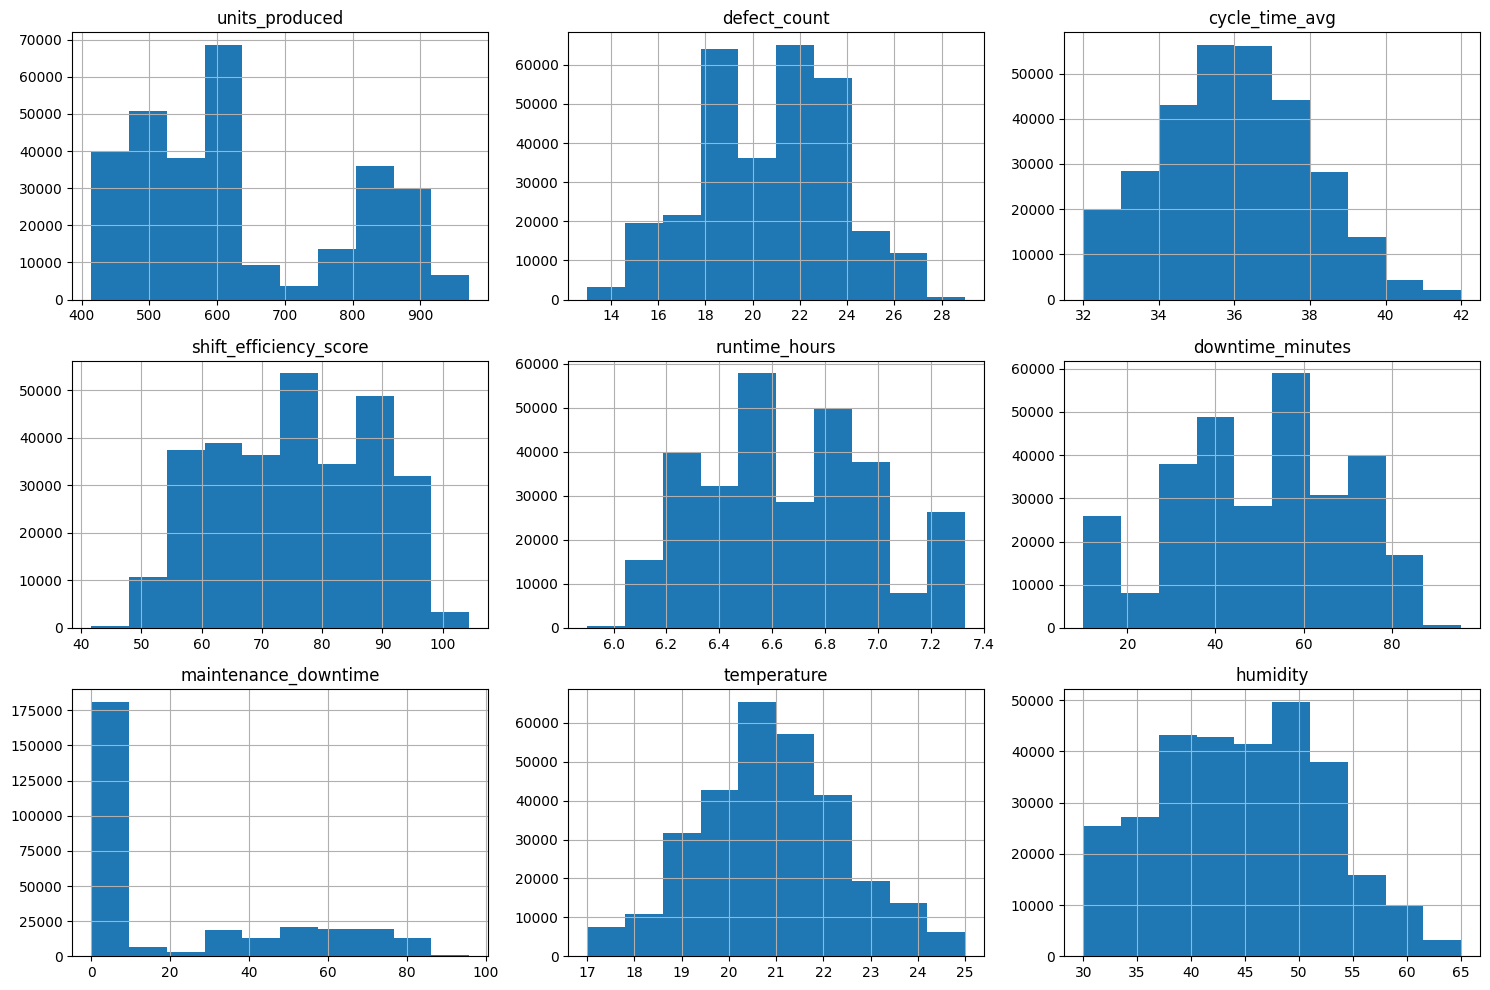

In [136]:
## Numerical Data Analysis

num_cols = [
    "units_produced", "defect_count", "cycle_time_avg",
    "shift_efficiency_score", "runtime_hours", "downtime_minutes", "maintenance_downtime",
    "temperature", "humidity"
]

Shift_Data[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

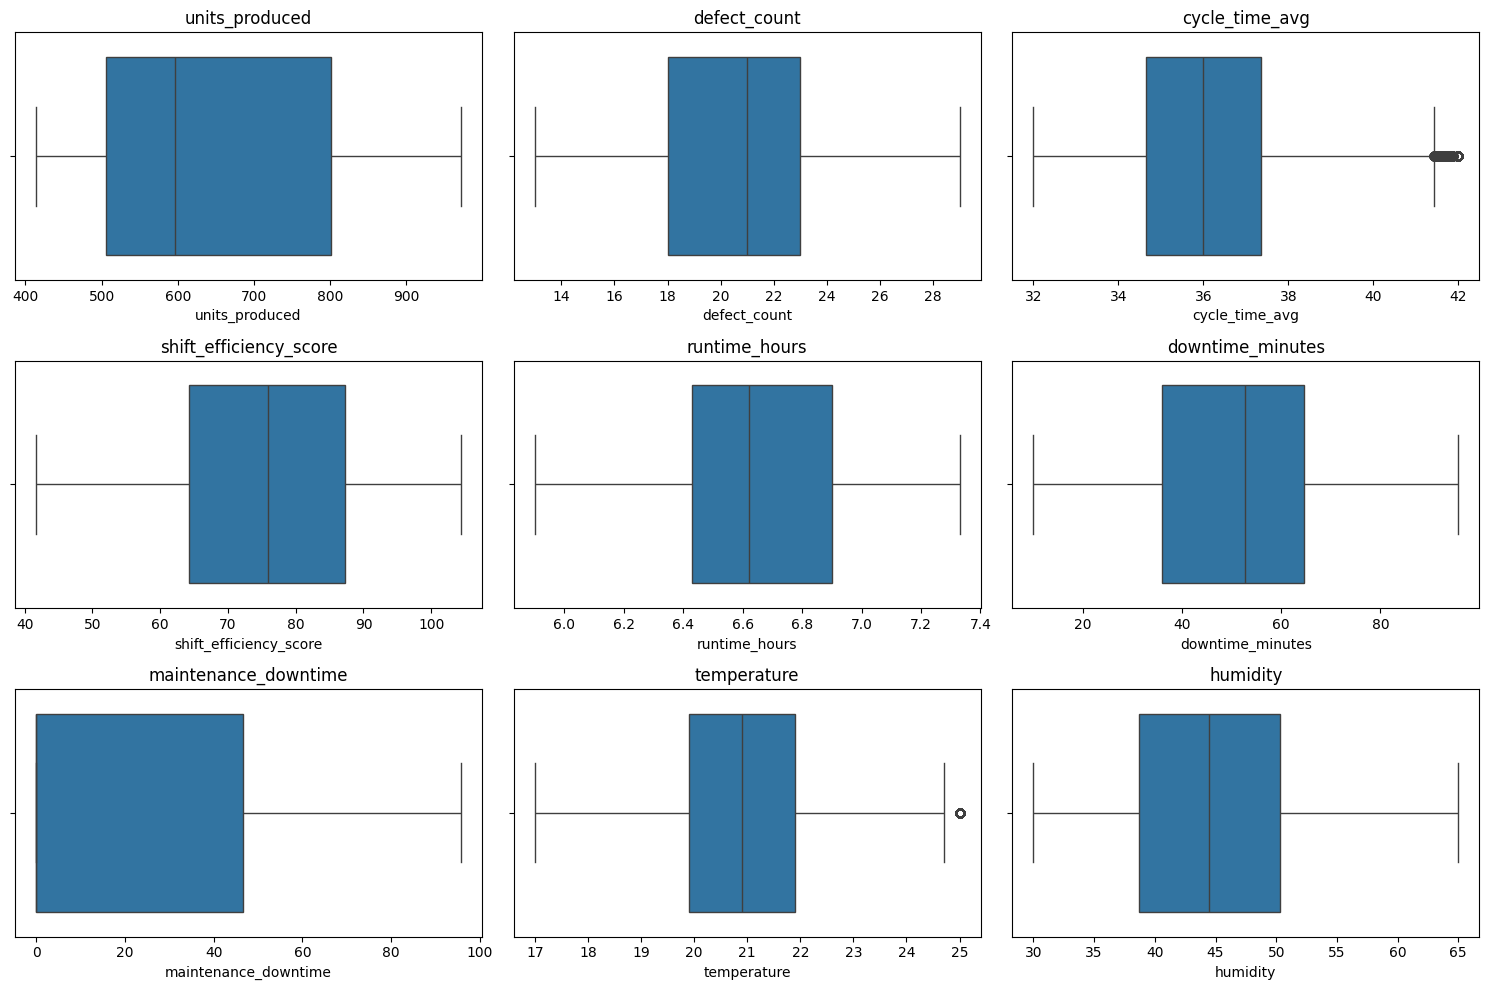

In [137]:
## Using the blox to check if our dataset has outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=Shift_Data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Categorical Variable Analysis

In [138]:
Categorical_cols = ["shift_name", "issue_type", "resolved_by",
                    "machine_status", "defect_type", "inspection_result",
                    "severity", "experience_level"]

for column in Categorical_cols:
    print(f"Value counts for {column}:\n")
    print(Shift_Data[column].value_counts())

Value counts for shift_name:

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
Value counts for issue_type:

issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
Value counts for resolved_by:

resolved_by
No Maintenace    181103
TECH_03           12537
TECH_07           12427
TECH_08           12290
TECH_02           12065
TECH_10           11977
TECH_05           11743
TECH_04           11275
TECH_01           10522
TECH_09           10441
TECH_06            9954
Name: count, dtype: int64
Value counts for machine_status:

machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
Value counts for defect_type:

defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
Value counts for inspection_result:

inspection_result

C:\Users\HP\AppData\Local\Temp\ipykernel_9008\1013706693.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette = 'coolwarm', ax=axes[index])
C:\Users\HP\AppData\Local\Temp\ipykernel_9008\1013706693.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette = 'coolwarm', ax=axes[index])
C:\Users\HP\AppData\Local\Temp\ipykernel_9008\1013706693.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x=column, y='count', palette = 'coolwarm', ax=axes[index])
C

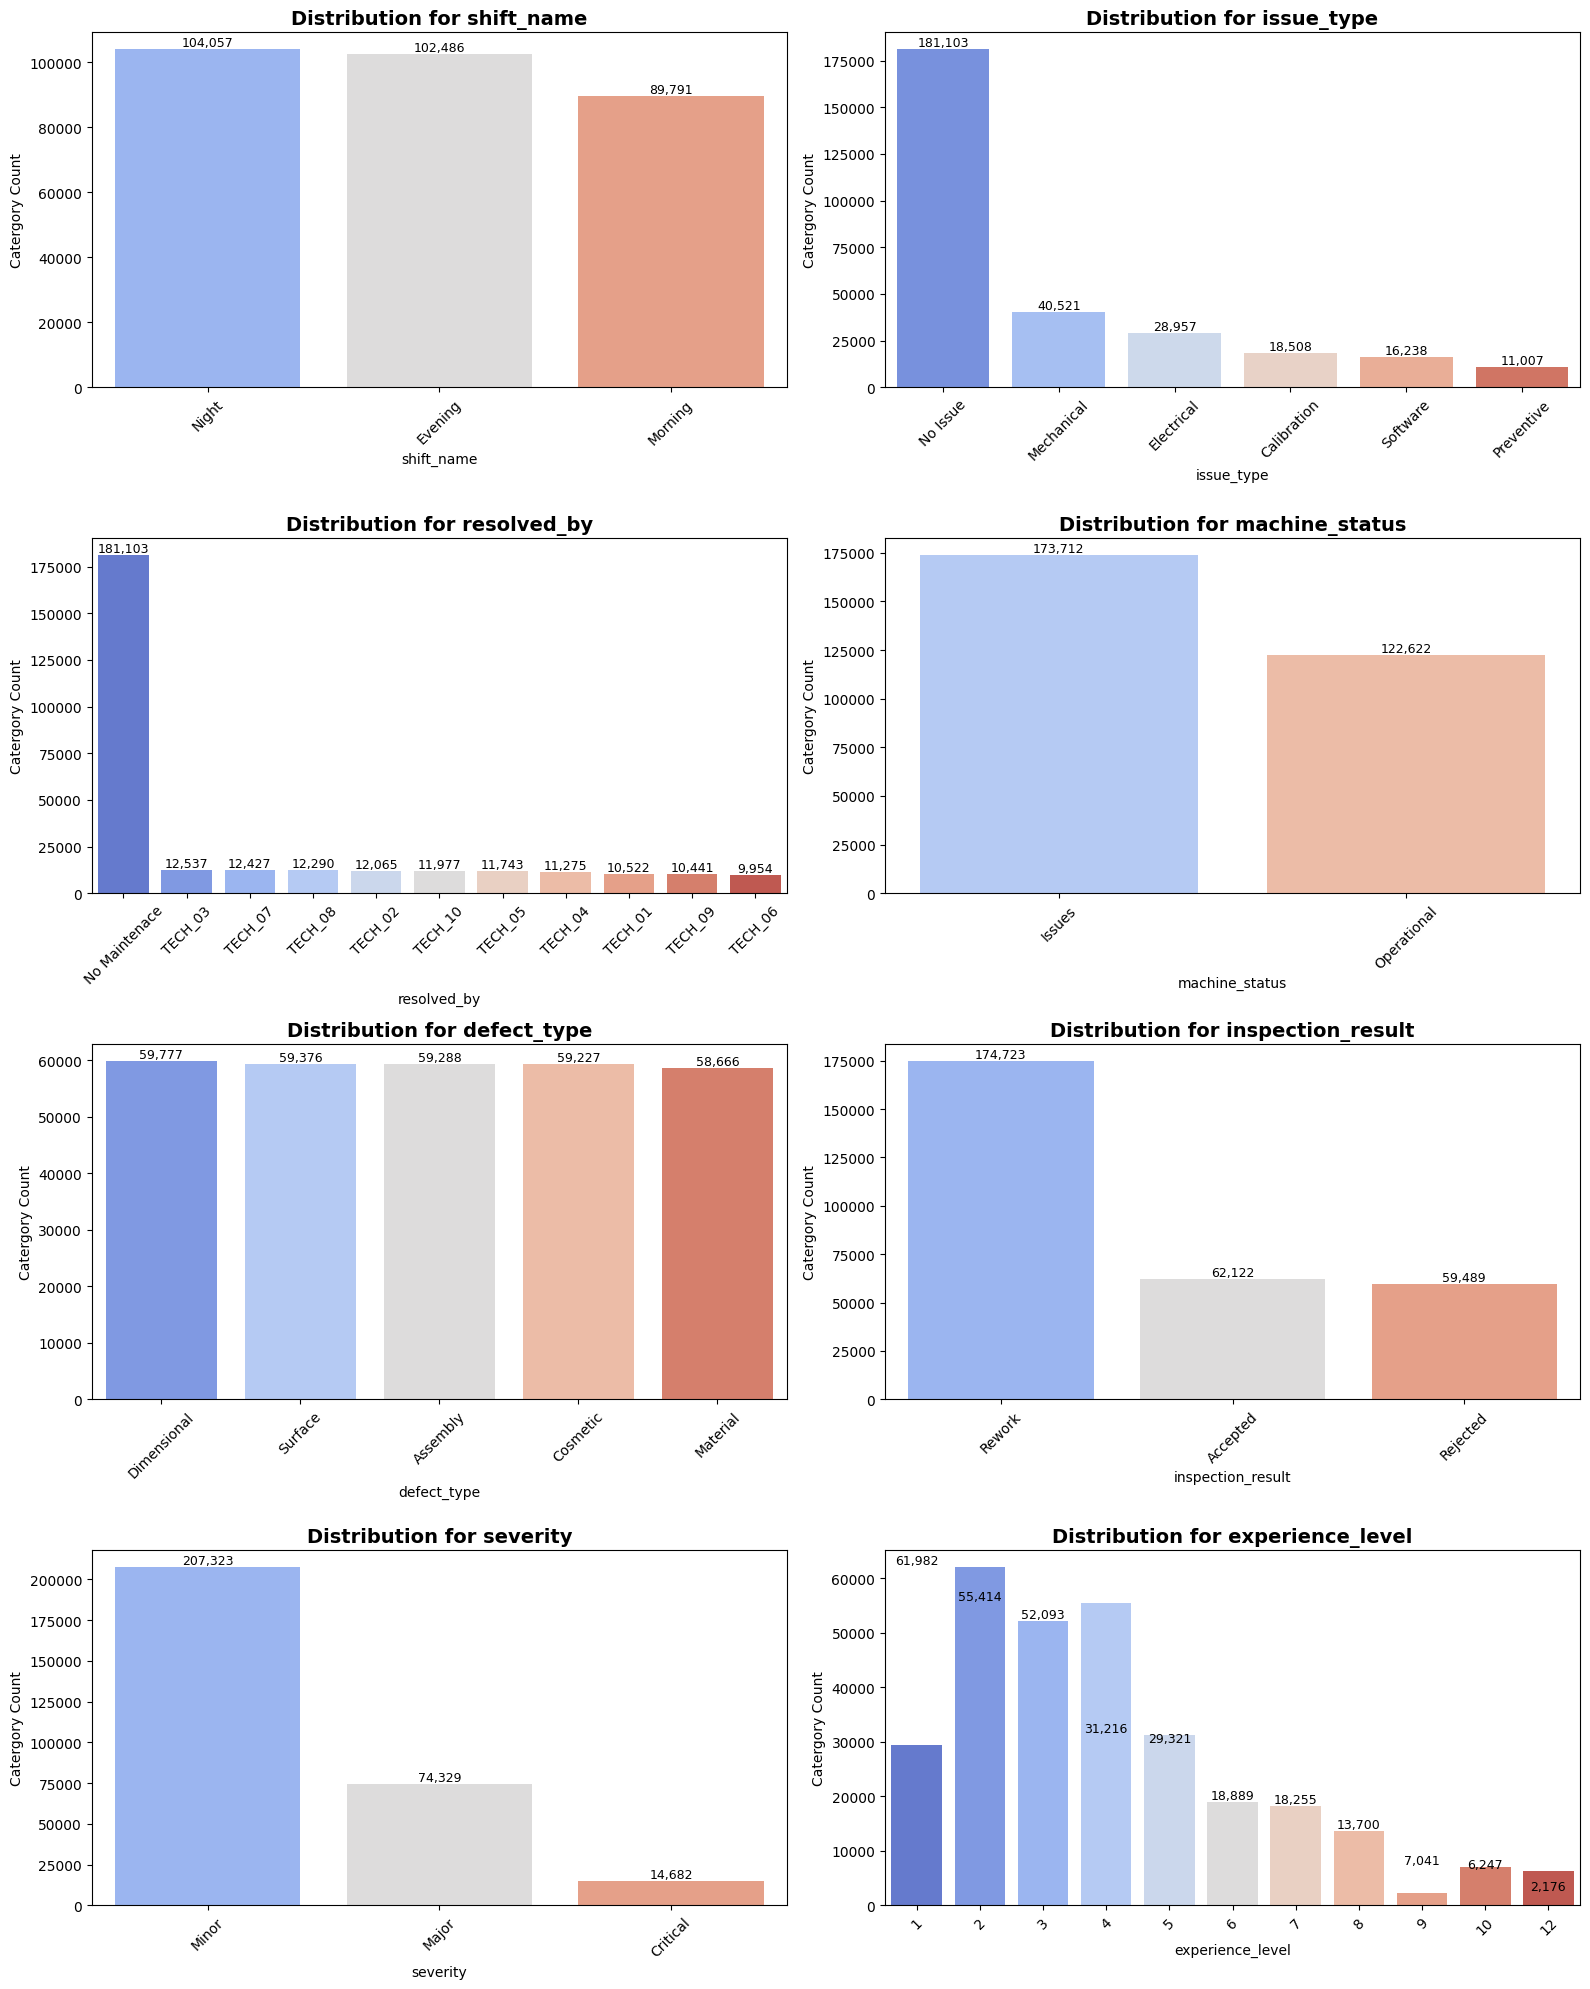

In [139]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

axes = axes.flatten()

for index, column in enumerate(Categorical_cols):
    # Get the values counts
    counts = Shift_Data[column].value_counts().reset_index()
    counts.columns = [column, 'count']

    sns.barplot(data=counts, x=column, y='count', palette = 'coolwarm', ax=axes[index])

    # plot customindexzation
    axes[index].tick_params(axis='x', rotation = 45)
    axes[index].set_title(f"Distribution for {column}", fontsize=14, fontweight='bold')
    axes[index].set_xlabel(column)
    axes[index].set_ylabel('Catergory Count')

    # add the value labels on the bar
    for j, v in enumerate(counts['count']):
        axes[index].text(j, v, f'{v:,}', ha='center', va = 'bottom', fontsize=9)

plt.tight_layout()
plt.show()



### Operational Performance during Maintainance vs No Maintainance

In [140]:
Shift_Data["maintenance_flag"].value_counts()

maintenance_flag
0    242487
1     53847
Name: count, dtype: int64

In [141]:
# Maintainance Flag Analysis
maintenance_data = Shift_Data.groupby("maintenance_flag")[num_cols].mean()

In [142]:
#         unit_produced defect_count avg_cycle, downtime_minutes, maintainance_downtime

# 0           700             20      10              80              20
# 1           500             25      19              120             200


# maintainance_flag unit_produced defect_count avg_cycle, downtime_minutes, maintainance_downtime
# 0                   700             20      10              80              20
# 1                   500             25      19              120             200




# maintainanace_flag 0    1
# unit_produced      700 500
# defect_count        20 25
# avg_cycle



In [143]:
maintenance_data.head()

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
maintenance_flag,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,49.281488,13.520254,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.954773,53.701075,20.860356,44.613007


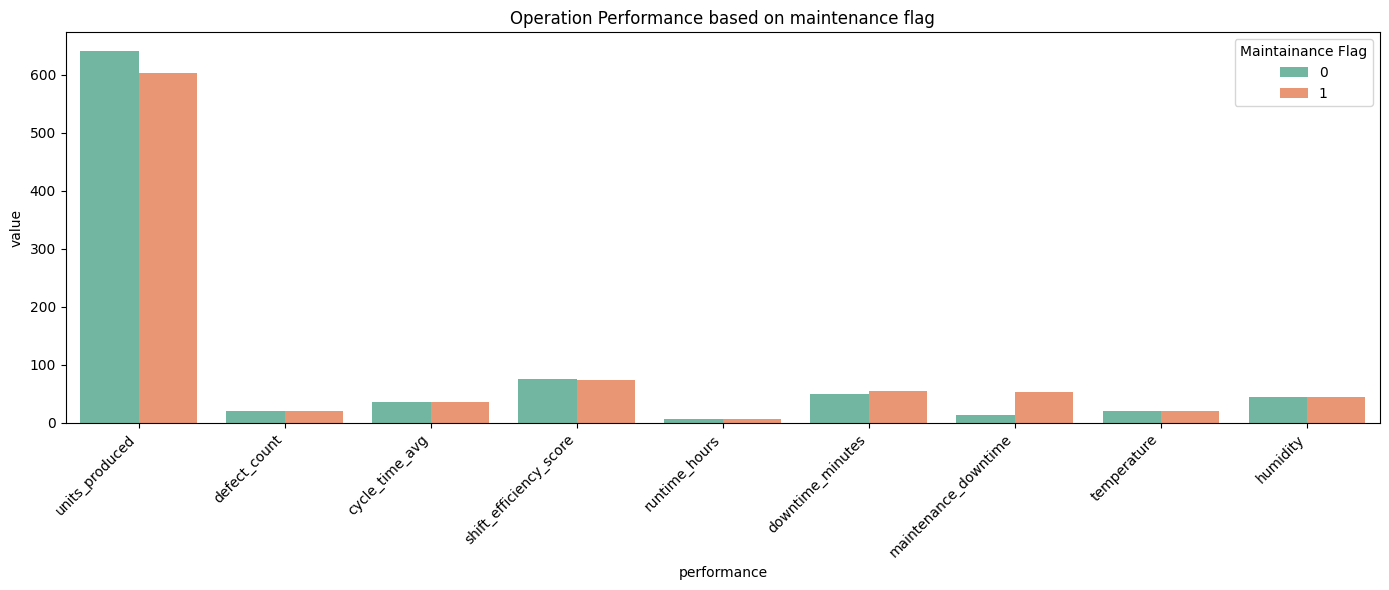

In [144]:
maintainance_data = maintenance_data.reset_index()
maintainance_plot_melt = maintainance_data.melt(
    id_vars = ["maintenance_flag"],
    var_name = "performance",
    value_name = 'value'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data = maintainance_plot_melt,
    x = "performance",
    y = "value",
    hue = "maintenance_flag",
    palette = 'Set2'
)

plt.xticks(rotation = 45, ha='right')
plt.title("Operation Performance based on maintenance flag")
plt.legend(title = "Maintainance Flag")
plt.tight_layout()
plt.show()

### Shift Performance Analysis

In [145]:
shift_performance_data = Shift_Data.groupby("shift_name").agg({
    "units_produced": ["mean", "sum"],
    "cycle_time_avg": "mean",
    "defect_count": "mean",
    "downtime_minutes": ["mean", "sum"],
    "shift_efficiency_score": "mean"
}).reset_index()


shift_performance_data.columns = [
    "shift_name", "average_units_produced", "total_units_produced",
    "average_cycle_time", "average_defect_count", "average_downtime", "total_downtime",
    "average_efficiency"
]

# calculate defect rate 
defect_sum = Shift_Data.groupby("shift_name")["defect_count"].sum().values
units_sum = Shift_Data.groupby("shift_name")["units_produced"].sum().values

shift_performance_data["defect_rate"] = (defect_sum / units_sum) * 100

shift_performance_data.sort_values(by="average_units_produced", ascending = False)


,shift_name,average_units_produced,total_units_produced,average_cycle_time,average_defect_count,average_downtime,total_downtime,average_efficiency,defect_rate
1,Morning,846.926073,76046339,35.999287,18.749151,29.086002,2611661.18,90.869944,2.213788
0,Evening,601.050543,61599266,36.025551,21.329079,50.569570,5182672.96,76.737957,3.548633
2,Night,484.765119,50443204,36.028043,21.670998,67.857893,7061088.73,61.164965,4.470412


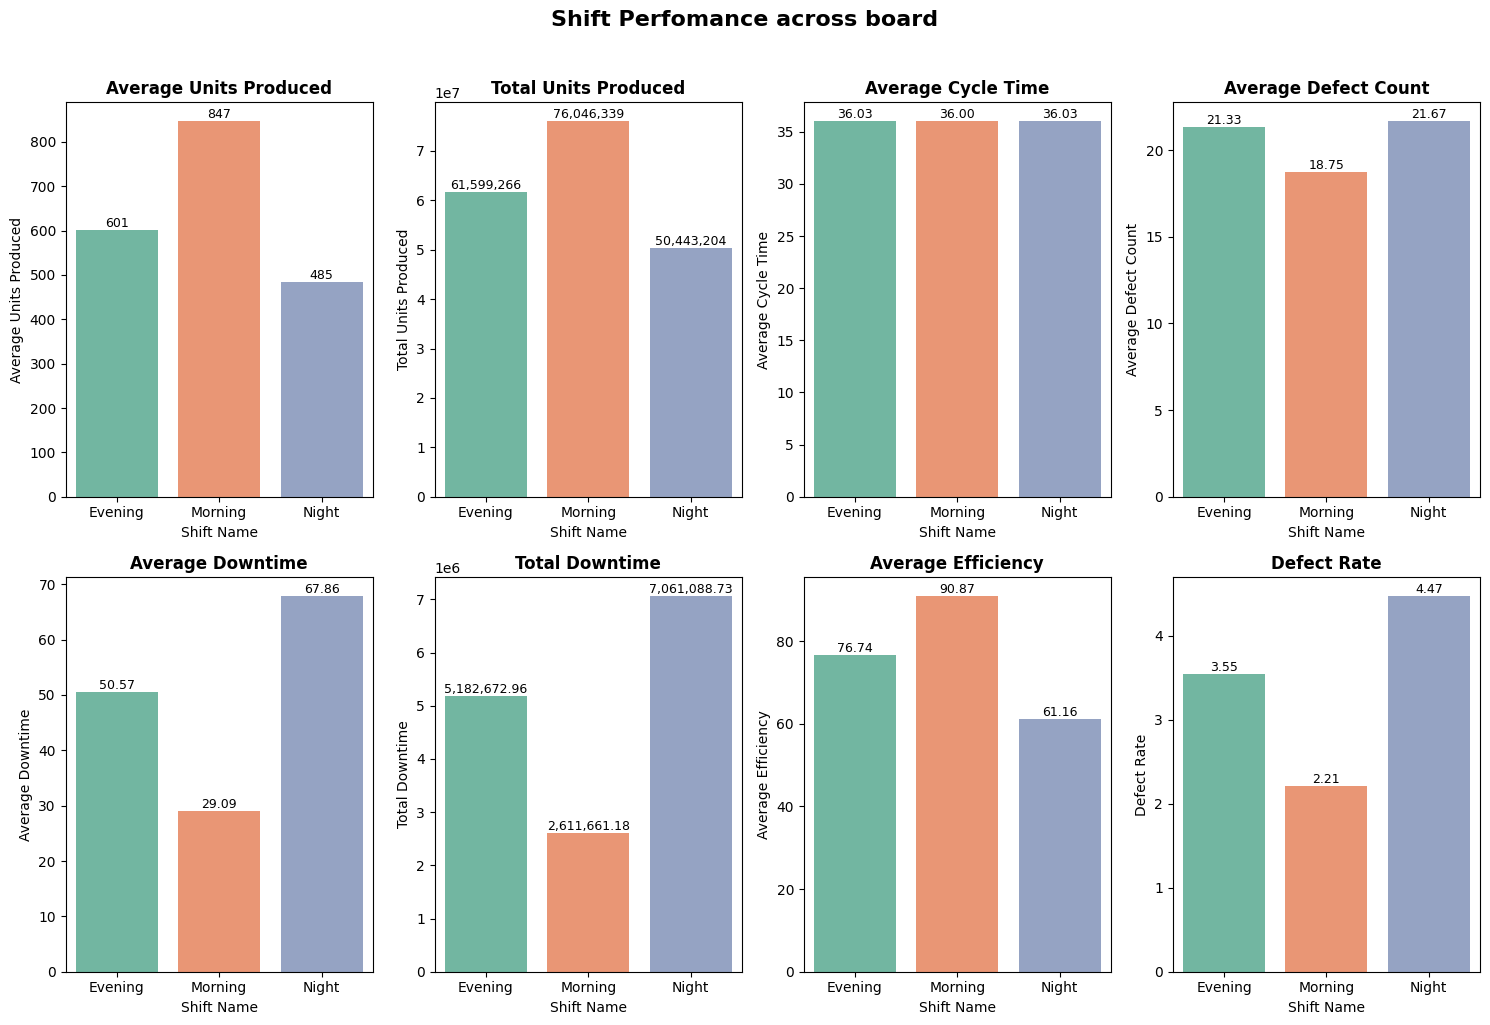

In [146]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))

axes = axes.flatten()

metrics = ["average_units_produced", "total_units_produced", "average_cycle_time", "average_defect_count", "average_downtime", "total_downtime",
            "average_efficiency", "defect_rate"]

for i, metric in enumerate(metrics):
    sns.barplot(data = shift_performance_data,
                x = 'shift_name',
                y =  metric,
                hue = 'shift_name',
                palette = "Set2",
                legend = False,
                ax = axes[i])
    axes[i].set_title(f'{metric.replace("_", " ").title()}', fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Shift Name")
    axes[i].set_ylabel(metric.replace("_", " ").title())

    for j, v in enumerate(shift_performance_data[metric]):
        if 'units' in metric:
            axes[i].text(j, v, f'{v:,.0f}', ha="center", va="bottom", fontsize = 9)
        else:
            axes[i].text(j, v, f'{v:,.2f}', ha="center", va="bottom", fontsize = 9)

plt.suptitle("Shift Perfomance across board", fontsize = 16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Shift Performance based on production output per hour

In [147]:
Shift_Data["total_operation_hours"] = Shift_Data["runtime_hours"] + (Shift_Data["downtime_minutes"] / 60)

output_per_hour = (
    Shift_Data.groupby("shift_name")
    .apply(lambda x:x["units_produced"].sum() / x["total_operation_hours"].sum())
    .rename("output_per_hour")
)
output_per_hour

C:\Users\HP\AppData\Local\Temp\ipykernel_9008\1302232115.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x:x["units_produced"].sum() / x["total_operation_hours"].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
Name: output_per_hour, dtype: float64

In [148]:
output_per_hour_data = output_per_hour.reset_index()

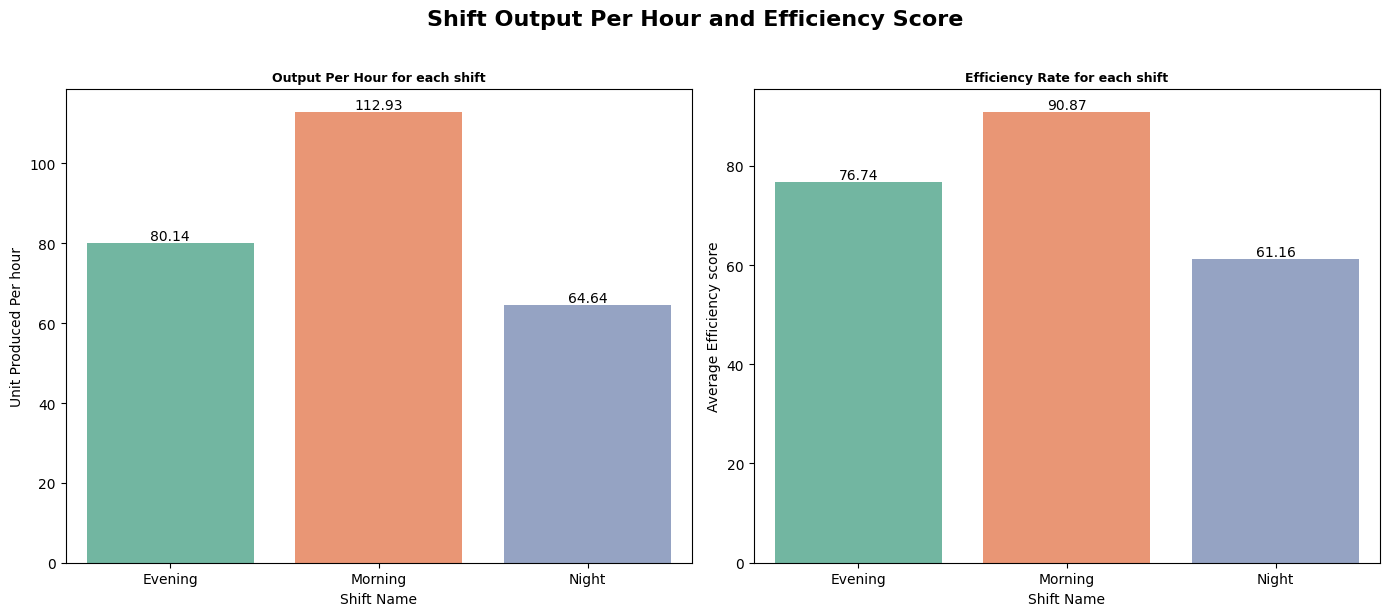

In [149]:


fig, axes = plt.subplots(1, 2,  figsize=(14, 6))

sns.barplot(
    data = output_per_hour_data,
    x = "shift_name",
    y = 'output_per_hour',
    hue = "shift_name",
    palette = "Set2",
    ax = axes[0],
    legend = False
)

axes[0].set_title("Output Per Hour for each shift", fontsize = 9, fontweight= 'bold')
axes[0].set_xlabel("Shift Name")
axes[0].set_ylabel("Unit Produced Per hour")
for i, v in enumerate(output_per_hour_data['output_per_hour']):
    axes[0].text(i, v, f'{v:.2f}', ha="center", va="bottom")

merged_data = shift_performance_data.merge(output_per_hour_data, on = "shift_name")
# Plot 2, plotting the shift efficiency score.

sns.barplot(
    data = merged_data,
    x = "shift_name",
    y = 'average_efficiency',
    hue = "shift_name",
    palette = "Set2",
    ax = axes[1],
    legend = False
)

axes[1].set_title("Efficiency Rate for each shift", fontsize = 9, fontweight= 'bold')
axes[1].set_xlabel("Shift Name")
axes[1].set_ylabel("Average Efficiency score")

for i, v in enumerate(merged_data['average_efficiency']):
    axes[1].text(i, v, f'{v:.2f}', ha="center", va="bottom")

plt.suptitle("Shift Output Per Hour and Efficiency Score", fontsize = 16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### OEE Calculation

The code calculates Overall Equipment Effectiveness (OEE) by:

1. **Separating production and machine data** - Creates distinct tables for production metrics (units, defects) and machine metrics (downtime)

2. **Computing three OEE components:**
   - **Availability** - Machine uptime percentage
   - **Performance** - Speed efficiency vs theoretical maximum  
   - **Quality** - Percentage of defect-free units

3. **Tracking monthly trends** - Calculates OEE per month and identifies performance degradation between months

**Why this matters:** OEE is a manufacturing industry standard that pinpoints whether productivity losses come from equipment downtime, slow operation speeds, or product defects.

## A Detailed Breakdown of what is happening:


A simple scenario breakdown of the OEE code and why it is important:

---

## Code Breakdown: A Factory Story

### Meet Our Factory

Imagine you run a **bottle factory**. Each machine should produce **100 bottles per hour** (theoretical rate). Each shift is **7.5 hours** (planned time).

---

### First Code Block: Organizing the Data

**Scenario:** You have a messy notebook with all your factory records mixed together.

```python
prod = (
    df[['production_id', 'shift_id', 'date', 'units_produced', 'defect_count']]
    .drop_duplicates(subset=['production_id'])
    .copy()
)
```

**What's happening:** You create a clean **Production Log** that shows:
- How many bottles were made
- How many were defective
- One entry per production run (no duplicates)

```python
mach = (
    df[['machine_id', 'shift_id', 'date', 'downtime_minutes']]
    .drop_duplicates()
    .copy()
)
```

**What's happening:** You create a separate **Maintenance Log** that shows:
- How many minutes each machine broke down
- Organized by machine, shift, and date

**Why separate them?** Because one machine might break down during multiple production runs. Keeping them separate prevents counting the same breakdown twice.

---

### Second Code Block: Calculating OEE (The Scorecard)

**Scenario:** Now you want to grade how well your factory performed each day.

#### Step 1: Calculate Availability (Was the machine running?)

```python
mach['avail_machine'] = 1 - mach['downtime_minutes']/(PLANNED*60)
```

**Simple explanation:** 
- Perfect score = 1.0 (100% available)
- Each minute of breakdown reduces the score

**Example:** 
- Your shift is 7.5 hours = 450 minutes
- Machine broke down for 45 minutes
- Availability = 1 - (45 ÷ 450) = 0.90 or 90%
- **Meaning:** Machine was running 90% of the time

#### Step 2: Calculate Performance (Did it run at full speed?)

```python
merged['performance'] = (merged['units_produced'] / (THEO * PLANNED)).clip(0,1)
```

**Simple explanation:**
- Perfect score = 1.0 (100% speed)
- Slower production reduces the score

**Example:**
- Theoretical speed = 100 bottles per hour
- Planned time = 7.5 hours
- Should have made: 100 × 7.5 = 750 bottles
- Actually made: 600 bottles
- Performance = 600 ÷ 750 = 0.80 or 80%
- **Meaning:** Machine ran at 80% of its target speed

#### Step 3: Calculate Quality (Were the bottles good?)

```python
merged['quality'] = 1 - merged['defect_count']/merged['units_produced']
```

**Simple explanation:**
- Perfect score = 1.0 (100% good products)
- Each defective product reduces the score

**Example:**
- Made 600 bottles
- 30 were cracked (defects)
- Quality = 1 - (30 ÷ 600) = 0.95 or 95%
- **Meaning:** 95% of bottles were good, 5% were defective

#### Step 4: Calculate Final OEE Score

```python
merged['oee_est'] = merged['availability'] * merged['performance'] * merged['quality']
```

**Example calculation:**
- Availability = 90% (0.90)
- Performance = 80% (0.80)
- Quality = 95% (0.95)

**OEE = 0.90 × 0.80 × 0.95 = 0.684 or 68.4%**

**What this means for the factory owner:**

| Score | Grade | What It Tells You |
|-------|-------|-------------------|
| 68.4% | C | You're losing 31.6% of potential production |
| | | - 10% lost to breakdowns |
| | | - 20% lost to slow speed |
| | | - 5% lost to defects |

---

### Monthly Tracking: Spotting Problems Early

```python
monthly_oee = merged.groupby('month')['oee_est'].mean()
```

**Scenario:** You track OEE for three months:

| Month | OEE | Change |
|-------|-----|--------|
| Month 1 | 75% | Starting point |
| Month 2 | 70% | ↓ 5% |
| Month 3 | 65% | ↓ 10% total |

```python
degradation = (m1 - m3) / m1 * 100
```

**Result:** 13.3% degradation

**What this tells you:** Something is getting worse over time. Machines might be aging, maintenance might be slipping, or operators might be struggling.

---

### The Big Picture: Why This Matters

**Without OEE:** "Our factory isn't producing enough" (vague problem)

**With OEE:** 
- "Availability is 90%" → Breakdowns are minimal ✓
- "Performance is 60%" → Machines running too slow ✗
- "Quality is 95%" → Defects are fine ✓

**Action Plan:** Focus on improving machine speed (performance), not breakdowns or quality.

---

### Summary Table

| OEE Component | Question It Answers | Example Problem |
|---------------|---------------------|-----------------|
| **Availability** | Was the machine running? | Breakdowns, changeovers |
| **Performance** | Was it running at full speed? | Slow operation, jams |
| **Quality** | Did it make good products? | Defects, scrap |
| **OEE** | Overall factory health? | Combined score |

**Perfect Factory (100% OEE):** 
- Machine never stops (100% availability)
- Always runs at full speed (100% performance)
- Every product is perfect (100% quality)

**Real World:** Most factories score 60-85%. The code helps you find exactly where you're losing points.

In [150]:
production = (
    Shift_Data[["production_id", "shift_id", "date", "units_produced", "defect_count"]]
    .drop_duplicates(subset=["production_id"])
    .copy()
)

machine = (
    Shift_Data[["machine_id", "date", "shift_id", "downtime_minutes"]]
    .drop_duplicates()
    .copy()
)

In [151]:
production.head()

,production_id,shift_id,date,units_produced,defect_count
0,1,1,2024-01-01,929,20
2308,102,3,2024-01-01,530,21
2309,103,3,2024-01-01,489,22
2331,104,3,2024-01-01,527,21
2281,101,3,2024-01-01,555,21


In [152]:
production.shape

(13650, 5)

In [153]:
machine.head()

,machine_id,date,shift_id,downtime_minutes
0,MC_001,2024-01-01,1,15.39
2308,MC_002,2024-01-01,3,53.73
2309,MC_003,2024-01-01,3,51.90
2331,MC_004,2024-01-01,3,54.45
2281,MC_001,2024-01-01,3,52.99


In [154]:
machine.shape

(13650, 4)

### OEE Metrics Calculation 

In [155]:
import os

PLANNED = globals().get('PLANNED_H', 7.5)
THEO = globals().get('THEO_RATE', 100.0)

### computer per machine availabilty
machine['available_machine'] = 1 - machine['downtime_minutes']/(PLANNED * 60)
machine['available_machine'] = machine["available_machine"].clip(0, 1)


available_machine_agg = (
    machine.groupby(['date', 'shift_id'])['available_machine']
    .mean()
    .reset_index()
    .rename(columns={'available_machine': 'machine_availability'})
)

In [156]:
available_machine_agg.head()

,date,shift_id,machine_availability
0,2024-01-01,1,0.963687
1,2024-01-01,2,0.920976
2,2024-01-01,3,0.881807
3,2024-01-02,1,0.965439
4,2024-01-02,2,0.919042


In [157]:
available_machine_agg.shape

(273, 3)

In [158]:
# merging availability into production
merged_production_data = production.merge(available_machine_agg, how="left", on=["date", "shift_id"])
merged_production_data['machine_availability'] = merged_production_data['machine_availability'].fillna(1)

# performance based on the planned time (not run time)
merged_production_data["performance"] = (merged_production_data['units_produced'] / (THEO * PLANNED)).clip(0, 1)

# Quality
merged_production_data["quality"] = 1 - merged_production_data["defect_count"] / merged_production_data["units_produced"]
merged_production_data['quality'] = merged_production_data['quality'].fillna(1).clip(0, 1)

# Final OEE estimate
merged_production_data['oee_est'] = merged_production_data['machine_availability'] * merged_production_data["performance"] * merged_production_data["quality"]


merged_production_data['month'] = merged_production_data['date'].dt.month


In [159]:
merged_production_data.head()

,production_id,shift_id,date,units_produced,defect_count,machine_availability,performance,quality,oee_est,month
0,1,1,2024-01-01,929,20,0.963687,1.000000,0.978471,0.942940,1
1,102,3,2024-01-01,530,21,0.881807,0.706667,0.960377,0.598453,1
2,103,3,2024-01-01,489,22,0.881807,0.652000,0.955010,0.549072,1
3,104,3,2024-01-01,527,21,0.881807,0.702667,0.960152,0.594926,1
4,101,3,2024-01-01,555,21,0.881807,0.740000,0.962162,0.627846,1


In [160]:
## monthly OEE (overall equipment effective for each of the month)
monthly_oee = (
    merged_production_data.groupby('month')['oee_est']
    .mean()
    .sort_index()
)

# print to confirm it matches the earlier value
for month, value in monthly_oee.items():
    print(f"Month {month} OEE: {value*100:.2f}%")



Month 1 OEE: 74.90%
Month 2 OEE: 68.53%
Month 3 OEE: 68.83%


In [161]:
if 1 in monthly_oee.index and 3 in monthly_oee.index:
    m1 = monthly_oee.loc[1]
    m3 = monthly_oee.loc[3]
    degradation = (m1 - m3) / m1 * 100
    print(f"Quaterly degradation (month 1 -> month 3): {degradation:.2f}")
else:
    print('could not find month 1 and 3 in the data to compute the degradation process or curve')

Quaterly degradation (month 1 -> month 3): 8.10


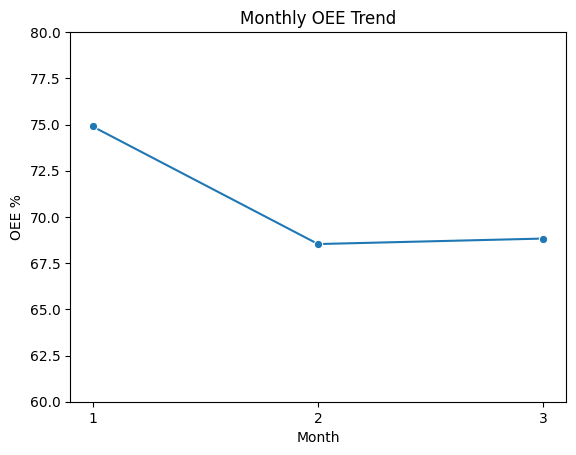

In [162]:
monthly_oee_df = monthly_oee.reset_index()
monthly_oee_df["OEE_percentage"] = monthly_oee_df['oee_est'] * 100

sns.lineplot(x='month', y = 'OEE_percentage', data = monthly_oee_df, marker = 'o')
plt.title("Monthly OEE Trend")
plt.ylabel('OEE %')
plt.ylim(60, 80)
plt.xticks([1, 2, 3])
plt.xlabel('Month')
plt.show()

## Experience vs the defect counts that occured during production

C:\Users\HP\AppData\Local\Temp\ipykernel_9008\3141742748.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = Shift_Data, x='experience_level', y='defect_count', palette = 'Set2')


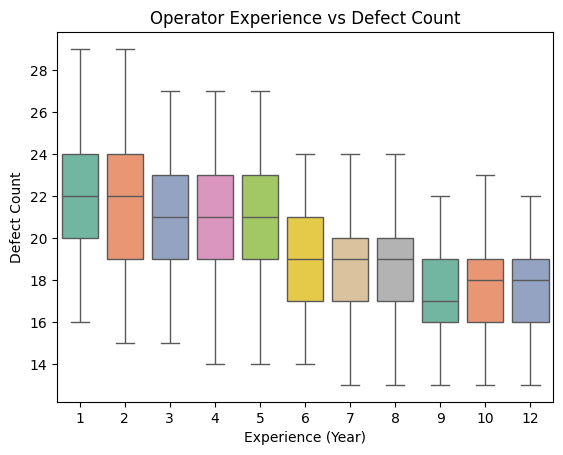

In [163]:
sns.boxplot(data = Shift_Data, x='experience_level', y='defect_count', palette = 'Set2')
plt.title('Operator Experience vs Defect Count')
plt.xlabel('Experience (Year)')
plt.ylabel('Defect Count')
plt.show()

## feature Engineering

In [164]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [165]:
# Engineering new features
import pandas as pd

Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])

# fixing the overnight shift and add 1 day where the end_time < start time
mask =  Shift_Data['end_time'] < Shift_Data['start_time']
Shift_Data.loc[mask, 'end_time'] = Shift_Data.loc[mask, 'end_time'] + pd.Timedelta(days=1)

# Shift Duration
Shift_Data['shift_duration'] = (Shift_Data['end_time'] - Shift_Data['start_time']).dt.total_seconds() / 3600

# Defect rate
Shift_Data['defect_rate'] = Shift_Data['defect_count'] / Shift_Data['units_produced'].replace(0, pd.NA)

Shift_Data['downtime_ratio'] = Shift_Data['downtime_minutes'] / (Shift_Data['shift_duration'] * 60)

# temporal feature
Shift_Data['day_of_week'] = Shift_Data['date'].dt.dayofweek
Shift_Data['hour_of_day'] = Shift_Data['start_time'].dt.hour




In [166]:
Shift_Data.shape

(296334, 36)

In [167]:
# drop identifers and leakage, and raw datetime columns

columns_to_drop = [
    #identifer
    'shift_id', 'operator_id', 'operator_name', 'machine_id', 'production_id', 'supervisor_id',
    # leakage
    'qc_id', 'resolved_by', 'timestamp','severity', 'inspection_result', 'hour_of_day',
    # Raw datetime columns
    'start_time', 'end_time', 'date', 'defect_type', 'total_operation_hours', 'defect_rate', 'downtime_ratio'
]

Shift_Data.drop(columns = columns_to_drop, inplace = True)

In [168]:
Shift_Data.columns

Index(['shift_name', 'units_produced', 'defect_count', 'cycle_time_avg',
       'shift_efficiency_score', 'experience_level', 'skill_category',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'issue_type', 'maintenance_downtime', 'temperature',
       'humidity', 'shift_duration', 'day_of_week'],
      dtype='object')

In [169]:
Shift_Data.duplicated().sum()

281692

In [170]:
Shift_Data.drop_duplicates(inplace=True)

In [171]:
Shift_Data.duplicated().sum()

0

## Modelling Phase

In [172]:
Shift_Data.isna().sum()

shift_name                0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
experience_level          0
skill_category            0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
temperature               0
humidity                  0
shift_duration            0
day_of_week               0
dtype: int64

In [173]:
Shift_Data.head()

,shift_name,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,skill_category,runtime_hours,downtime_minutes,maintenance_flag,machine_status,issue_type,maintenance_downtime,temperature,humidity,shift_duration,day_of_week
0,Morning,929,20,35.65,95.945255,7,Expert,7.24,15.39,0,Operational,No Issue,0.00,22.3,49.9,8.0,0
2308,Night,530,21,35.61,66.604731,5,Intermediate,6.60,53.73,0,Issues,No Issue,0.00,22.3,49.9,8.0,0
2309,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,Issues,No Issue,0.00,22.3,49.9,8.0,0
2331,Night,527,21,38.87,65.059835,4,Intermediate,6.59,54.45,1,Issues,Mechanical,54.45,22.3,49.9,8.0,0
2281,Night,555,21,35.64,66.953888,2,Intermediate,6.62,52.99,0,Issues,No Issue,0.00,22.3,49.9,8.0,0


In [174]:
Shift_Data['shift_efficiency_score'].describe()

count    14642.000000
mean        76.229017
std         12.997940
min         41.690033
25%         65.024906
50%         76.652695
75%         88.082825
max        104.379285
Name: shift_efficiency_score, dtype: float64

## Data Splitting

In [175]:
X = Shift_Data.drop(columns=["shift_efficiency_score"])
y = Shift_Data["shift_efficiency_score"]

In [176]:
X.head()

,shift_name,units_produced,defect_count,cycle_time_avg,experience_level,skill_category,runtime_hours,downtime_minutes,maintenance_flag,machine_status,issue_type,maintenance_downtime,temperature,humidity,shift_duration,day_of_week
0,Morning,929,20,35.65,7,Expert,7.24,15.39,0,Operational,No Issue,0.00,22.3,49.9,8.0,0
2308,Night,530,21,35.61,5,Intermediate,6.60,53.73,0,Issues,No Issue,0.00,22.3,49.9,8.0,0
2309,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,No Issue,0.00,22.3,49.9,8.0,0
2331,Night,527,21,38.87,4,Intermediate,6.59,54.45,1,Issues,Mechanical,54.45,22.3,49.9,8.0,0
2281,Night,555,21,35.64,2,Intermediate,6.62,52.99,0,Issues,No Issue,0.00,22.3,49.9,8.0,0


In [177]:
y.head()

0       95.945255
2308    66.604731
2309    61.238523
2331    65.059835
2281    66.953888
Name: shift_efficiency_score, dtype: float64

In [178]:
# Splitting the data into training and testing

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [179]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(11713, 16)
(2929, 16)
(11713,)
(2929,)


In [180]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

Numerical_features = ['units_produced', 'defect_count', 'cycle_time_avg', 'experience_level',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag', 'maintenance_downtime',
        'temperature', 'humidity', 'shift_duration', 'day_of_week']

Categorical_features = [
    'shift_name', 
    'skill_category',
    'machine_status', 
]

preprocess = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore'), Categorical_features),
        ('num', 'passthrough',  Numerical_features)
    ]
)


In [181]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import dagshub
dagshub.init(repo_owner='babatundejulius911', repo_name='NordexShiftOptimizationSystem', mlflow=True)


models = {
    "LinearRegressionModel": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}

results = {}
fitted_pipeline = {}

mlflow.set_experiment("Nordex_Shift_Optimization_models")

for name, model in models.items():

    with mlflow.start_run(run_name = name):

        # creating the pipeline
        pipeline = Pipeline(steps=[
            ('pre_process', preprocess),
            ('ml_model', model)
        ])

        # Training the models on the train data
        pipeline.fit(X_train, y_train)
        # getting the models to predict the test data
        y_pred = pipeline.predict(X_test)

        # Defining Metrics
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        results[name] ={"r2": r2, "mae": mae, "mse":mse} 

        fitted_pipeline[name] = pipeline

        # Mlflow logging
        mlflow.log_param("model_name", name)

        if hasattr(model, "get_params"):
            for param_key, param_value in model.get_params().items():
                mlflow.log_param(param_key, param_value)

        mlflow.log_metric("r2", r2)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("mse", mse)

        mlflow.sklearn.log_model(pipeline, artifact_path="model")

        print(f"{name} -> R2: {r2:.4f}, MAE {mae:.4f}")




Initialized MLflow to track repo "babatundejulius911/NordexShiftOptimizationSystem"

Repository babatundejulius911/NordexShiftOptimizationSystem initialized!

2026/06/04 22:22:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 22:23:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LinearRegressionModel -> R2: 0.9354, MAE 2.6575
🏃 View run LinearRegressionModel at: https://dagshub.com/babatundejulius911/NordexShiftOptimizationSystem.mlflow/#/experiments/0/runs/a66f22c45565417381e4359e60e524d7
🧪 View experiment at: https://dagshub.com/babatundejulius911/NordexShiftOptimizationSystem.mlflow/#/experiments/0


2026/06/04 22:24:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 22:24:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForest -> R2: 0.9463, MAE 2.3594
🏃 View run RandomForest at: https://dagshub.com/babatundejulius911/NordexShiftOptimizationSystem.mlflow/#/experiments/0/runs/737f27b1853e4531935acd99042e8d51
🧪 View experiment at: https://dagshub.com/babatundejulius911/NordexShiftOptimizationSystem.mlflow/#/experiments/0


2026/06/04 22:28:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 22:29:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


GradientBoosting -> R2: 0.9472, MAE 2.3966
🏃 View run GradientBoosting at: https://dagshub.com/babatundejulius911/NordexShiftOptimizationSystem.mlflow/#/experiments/0/runs/fc8f9b2c652d47b781c0fbdfeb06a763
🧪 View experiment at: https://dagshub.com/babatundejulius911/NordexShiftOptimizationSystem.mlflow/#/experiments/0
